<a href="https://colab.research.google.com/github/NguyenThai365/pka-google-colab-notebook/blob/main/%5BDeepLearning%5D_23010531_Ph%C3%A2n_lo%E1%BA%A1i_%E1%BA%A3nh_040526.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Thiết lập môi trường, seed và kết nối Google Drive**

In [101]:
import os
import random
import numpy as np
import tensorflow as tf
import zipfile
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping, ReduceLROnPlateau
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [82]:
# Thiết lập seed
SEED = 42
os.environ['seed'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [83]:
# Kết nối Google Drive lưu Model/Logs
from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/[DL] Phân_loại_ảnh_040526'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Dữ liệu và Model sẽ được lưu tại: {PROJECT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dữ liệu và Model sẽ được lưu tại: /content/drive/MyDrive/[DL] Phân_loại_ảnh_040526


# **Giải nén dữ liệu**

In [84]:
def extract_data(zip_path, extract_to):
  if os.path.exists(zip_path):
    if not os.path.exists(extract_to):
      print(f"Đang giải nén {zip_path}...")
      with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/dataset/')
      print(f"Đã giải nén xong {zip_path}")
    else:
      print(f"Thư mục {extract_to} đã tồn tại, bỏ qua giải nén.")
  else:
    print(f"LỖI: Không tìm thấy file {zip_path}.")

In [85]:
# Tạo thư mục chứa dataset
os.makedirs('/content/dataset', exist_ok=True)
# Giải nén
extract_data('/content/training_set.zip', '/content/dataset/training_set')
extract_data('/content/test_set.zip', '/content/dataset/test_set')
# Path sau khi giải nén
train_dir = '/content/dataset/training_set'
test_dir = '/content/dataset/test_set'

Thư mục /content/dataset/training_set đã tồn tại, bỏ qua giải nén.
Thư mục /content/dataset/test_set đã tồn tại, bỏ qua giải nén.


# **Khám phá dữ liệu (EDA)**

In [86]:
def explore_data(directory):
  categories = ['cats', 'dogs']
  total_images = 0

  print(f"Dữ liệu: {directory}")
  for category in categories:
    folder_path = os.path.join(directory, category)
    # Bỏ qua nếu thư mục không tồn tại
    if not os.path.exists(folder_path): continue

    images = os.listdir(folder_path)
    total_images += len(images)
    print(f"Số lượng ảnh {category}: {len(images)}")

    if len(images) > 0:
      sample_img_path = os.path.join(folder_path, images[0])
      img = cv2.imread(sample_img_path)
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Chuyển hệ màu OpenCV sang RGB
      print(f"Kích thước 1 ảnh mẫu của {category} (height, width, channels): {img.shape}")

  print(f"Tổng số ảnh: {total_images}\n")

In [87]:
explore_data(train_dir)

Dữ liệu: /content/dataset/training_set
Số lượng ảnh cats: 4000
Kích thước 1 ảnh mẫu của cats (height, width, channels): (239, 320, 3)
Số lượng ảnh dogs: 4000
Kích thước 1 ảnh mẫu của dogs (height, width, channels): (374, 500, 3)
Tổng số ảnh: 8000



In [88]:
explore_data(test_dir)

Dữ liệu: /content/dataset/test_set
Số lượng ảnh cats: 1000
Kích thước 1 ảnh mẫu của cats (height, width, channels): (331, 450, 3)
Số lượng ảnh dogs: 1000
Kích thước 1 ảnh mẫu của dogs (height, width, channels): (425, 418, 3)
Tổng số ảnh: 2000



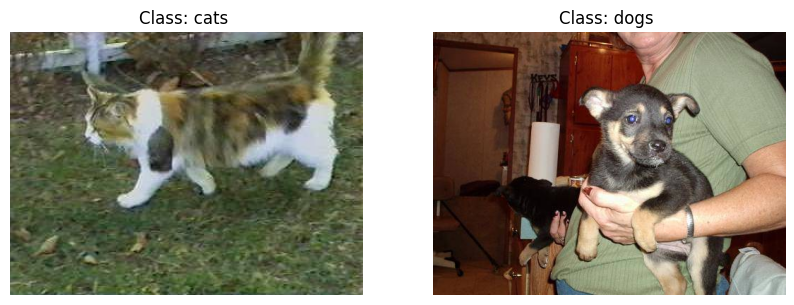

In [89]:
plt.figure(figsize=(10, 5))
for i, category in enumerate(['cats', 'dogs']):
  folder_path = os.path.join(train_dir, category)
  if os.path.exists(folder_path):
    img_name = os.listdir(folder_path)[0]
    img_path = os.path.join(folder_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 2, i+1)
    plt.imshow(img)
    plt.title(f"Class: {category} ")
    plt.axis('off')
plt.show()

# **Tiền xử lý dữ liệu**

In [90]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [91]:
# Rescale pixel về 0-1 và áp dụng Augmentation (chỉ áp dụng cho tập train)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
test_datagen = ImageDataGenerator(rescale=1./255)

In [92]:
print("Đang load tập training")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED
)

Đang load tập training
Found 8000 images belonging to 2 classes.


In [93]:
print("Đang load tập test")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=SEED
)

Đang load tập test
Found 2000 images belonging to 2 classes.


In [94]:
class_names = train_generator.class_indices
print("Nhãn:", class_names)

Nhãn: {'cats': 0, 'dogs': 1}


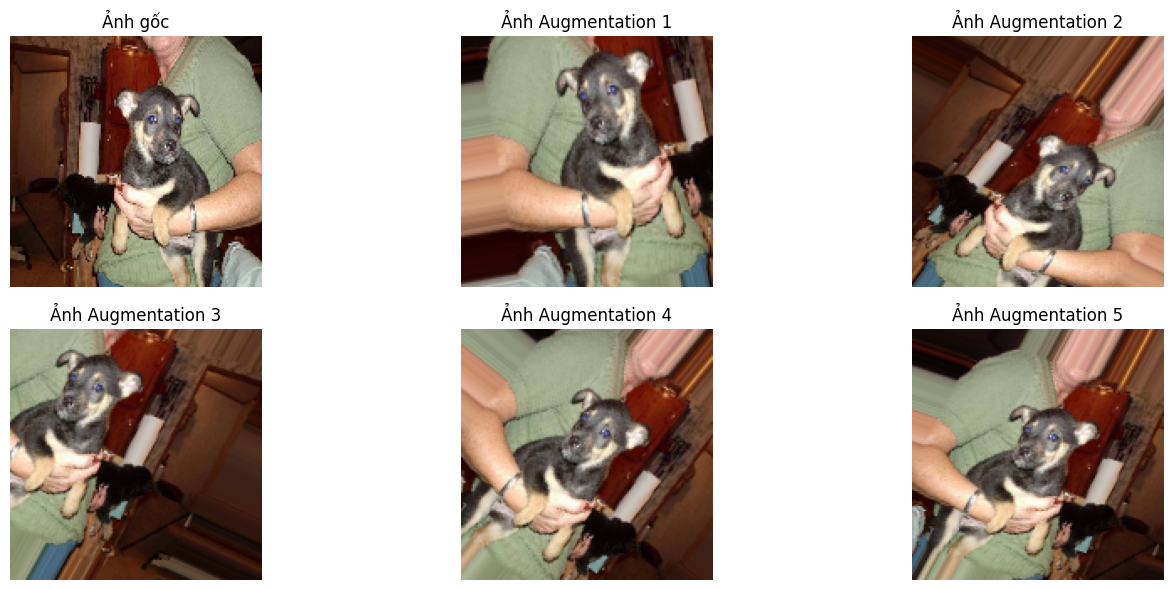

In [95]:
sample_folder = os.path.join(train_dir, 'dogs')
sample_img_name = os.listdir(sample_folder)[0]
sample_img_path = os.path.join(sample_folder, sample_img_name)

# Load ảnh và chuyển về mảng numpy
img = image.load_img(sample_img_path, target_size=IMG_SIZE)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

# Hiển thị ảnh
plt.figure(figsize=(15, 6))
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("Ảnh gốc")
plt.axis('off')

i = 2
for batch in train_datagen.flow(x, batch_size=1, seed=SEED):
  plt.subplot(2, 3, i)
  plt.imshow(batch[0])
  plt.title(f"Ảnh Augmentation {i-1}")
  plt.axis('off')
  i += 1
  if i > 6:
    break

plt.tight_layout()
plt.show()

# **Build và train model**

In [96]:
MODEL_PATH = os.path.join(PROJECT_DIR, 'cnn_dog_cat_model.h5')
LOG_PATH = os.path.join(PROJECT_DIR, 'training_log.csv')

In [97]:
def build_model():
  model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
  ])

  model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])
  return model

Chưa có model. Bắt đầu quá trình xây dựng và huấn luyện.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,297 (434.75 KB)

...


Epoch 26: finished saving model to /content/drive/MyDrive/[DL] Phân_loại_ảnh_040526/cnn_dog_cat_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 63s 254ms/step - accuracy: 0.8196 - loss: 0.3893 - val_accuracy: 0.8390 - val_loss: 0.3718
Epoch 27/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.8306 - loss: 0.3795
Epoch 27: val_accuracy did not improve from 0.83900
250/250 ━━━━━━━━━━━━━━━━━━━━ 64s 256ms/step - accuracy: 0.8284 - loss: 0.3818 - val_accuracy: 0.8020 - val_loss: 0.4564
Epoch 28/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.8447 - loss: 0.3644
Epoch 28: val_accuracy did not improve from 0.83900
250/250 ━━━━━━━━━━━━━━━━━━━━ 62s 246ms/step - accuracy: 0.8388 - loss: 0.3712 - val_accuracy: 0.8035 - val_loss: 0.4610
Epoch 29/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.8285 - loss: 0.3739
Epoch 29: val_accuracy did not improve from 0.83900
250/250 ━━━━━━━━━━━━━━━━━━━━ 61s 245ms/step - accuracy: 0.8319 - loss: 0.3694 - val_accuracy: 0.7050 - val_loss


Epoch 31: finished saving model to /content/drive/MyDrive/[DL] Phân_loại_ảnh_040526/cnn_dog_cat_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 64s 255ms/step - accuracy: 0.8354 - loss: 0.3638 - val_accuracy: 0.8425 - val_loss: 0.3447
Epoch 32/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.8349 - loss: 0.3626
Epoch 32: val_accuracy did not improve from 0.84250
250/250 ━━━━━━━━━━━━━━━━━━━━ 62s 247ms/step - accuracy: 0.8395 - loss: 0.3613 - val_accuracy: 0.8090 - val_loss: 0.4350
Epoch 33/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.8438 - loss: 0.3592
Epoch 33: val_accuracy improved from 0.84250 to 0.86050, saving model to /content/drive/MyDrive/[DL] Phân_loại_ảnh_040526/cnn_dog_cat_model.h5



Epoch 33: finished saving model to /content/drive/MyDrive/[DL] Phân_loại_ảnh_040526/cnn_dog_cat_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 64s 255ms/step - accuracy: 0.8455 - loss: 0.3553 - val_accuracy: 0.8605 - val_loss: 0.3379
Epoch 34/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8433 - loss: 0.3559
Epoch 34: val_accuracy did not improve from 0.86050
250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 240ms/step - accuracy: 0.8409 - loss: 0.3585 - val_accuracy: 0.7625 - val_loss: 0.5222
Epoch 35/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.8450 - loss: 0.3478
Epoch 35: val_accuracy improved from 0.86050 to 0.87500, saving model to /content/drive/MyDrive/[DL] Phân_loại_ảnh_040526/cnn_dog_cat_model.h5



Epoch 35: finished saving model to /content/drive/MyDrive/[DL] Phân_loại_ảnh_040526/cnn_dog_cat_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 63s 251ms/step - accuracy: 0.8476 - loss: 0.3437 - val_accuracy: 0.8750 - val_loss: 0.3028
Epoch 36/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.8569 - loss: 0.3301
Epoch 36: val_accuracy did not improve from 0.87500
250/250 ━━━━━━━━━━━━━━━━━━━━ 61s 244ms/step - accuracy: 0.8540 - loss: 0.3360 - val_accuracy: 0.6950 - val_loss: 0.8418
Epoch 37/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8475 - loss: 0.3399
Epoch 37: val_accuracy did not improve from 0.87500
250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 242ms/step - accuracy: 0.8451 - loss: 0.3450 - val_accuracy: 0.7825 - val_loss: 0.5808
Epoch 38/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8535 - loss: 0.3305
Epoch 38: val_accuracy did not improve from 0.87500
250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 242ms/step - accuracy: 0.8474 - loss: 0.3404 - val_accuracy: 0.7965 - val_loss


Epoch 46: finished saving model to /content/drive/MyDrive/[DL] Phân_loại_ảnh_040526/cnn_dog_cat_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 63s 253ms/step - accuracy: 0.8602 - loss: 0.3154 - val_accuracy: 0.8785 - val_loss: 0.2937
Epoch 47/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8569 - loss: 0.3242
Epoch 47: val_accuracy did not improve from 0.87850
250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 241ms/step - accuracy: 0.8634 - loss: 0.3167 - val_accuracy: 0.8680 - val_loss: 0.3323
Epoch 48/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8645 - loss: 0.3095
Epoch 48: val_accuracy did not improve from 0.87850
250/250 ━━━━━━━━━━━━━━━━━━━━ 63s 251ms/step - accuracy: 0.8651 - loss: 0.3145 - val_accuracy: 0.6425 - val_loss: 2.0607
Epoch 49/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8671 - loss: 0.3022
Epoch 49: val_accuracy did not improve from 0.87850
250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 242ms/step - accuracy: 0.8659 - loss: 0.3109 - val_accuracy: 0.7400 - val_loss

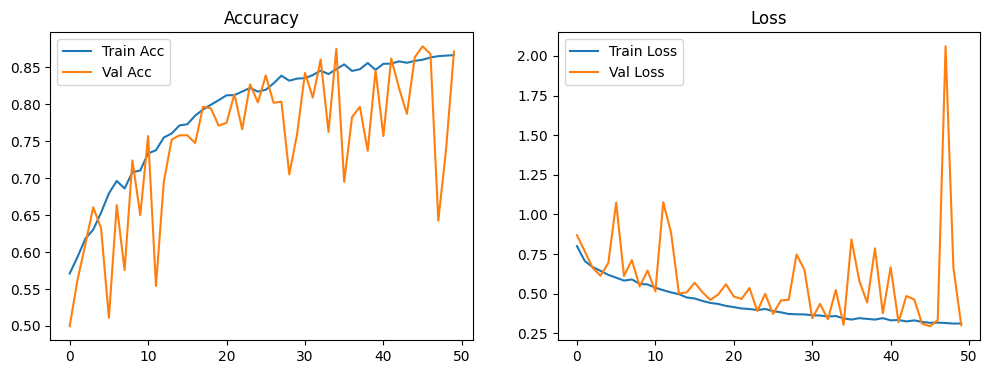

In [98]:
if os.path.exists(MODEL_PATH):
  print("Đã tìm thấy model. Đang tải model.")
  model = load_model(MODEL_PATH)

  if os.path.exists(LOG_PATH):
    logs = pd.read_csv(LOG_PATH)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(logs['accuracy'], label='Train Acc'); plt.plot(logs['val_accuracy'], label='Val Acc')
    plt.title('Accuracy'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(logs['loss'], label='Train Loss'); plt.plot(logs['val_loss'], label='Val Loss')
    plt.title('Loss'); plt.legend()
    plt.show()
else:
  print("Chưa có model. Bắt đầu quá trình xây dựng và huấn luyện.")
  model = build_model()
  model.summary()

  # Callbacks để lưu log và lưu model tốt nhất. Đồng thời thiết lập early stopping
  checkpoint = ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
  csv_logger = CSVLogger(LOG_PATH, append=False)
  early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
  )
  reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
  )

  # train model
  history = model.fit(
      train_generator,
      epochs=50,
      validation_data=test_generator,
      callbacks=[checkpoint, csv_logger]
  )

  # Plot sau khi train
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs_range = range(len(acc))
  plt.figure(figsize=(12, 4))
  plt.subplot(1, 2, 1)
  plt.plot(epochs_range, acc, label='Train Acc')
  plt.plot(epochs_range, val_acc, label='Val Acc')
  plt.title('Accuracy')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(epochs_range, loss, label='Train Loss')
  plt.plot(epochs_range, val_loss, label='Val Loss')
  plt.title('Loss')
  plt.legend()
  plt.show()

In [100]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,485 (1.27 MB)

 Trainable params: 110,593 (432.00 KB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 221,188 (864.02 KB)

# **Đánh giá model**

In [106]:
print("Đang dự đoán trên tập Test...")
test_generator.reset()

# Dự đoán
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).reshape(-1)
y_true = test_generator.classes

Đang dự đoán trên tập Test...
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step


In [107]:
print(classification_report(y_true, y_pred, target_names=['Cats (0)', 'Dogs (1)']))

              precision    recall  f1-score   support

    Cats (0)       0.83      0.93      0.88      1000
    Dogs (1)       0.92      0.81      0.86      1000

    accuracy                           0.87      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.88      0.87      0.87      2000



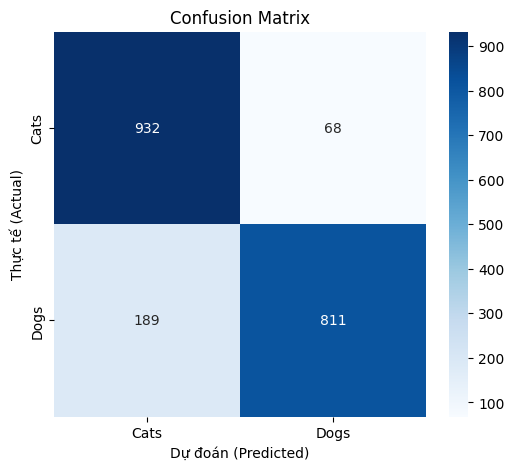

In [108]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cats', 'Dogs'], yticklabels=['Cats', 'Dogs'])
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Confusion Matrix')
plt.show()